<a href="https://colab.research.google.com/github/OrenLob/Network-Anomaly-Detection/blob/main/Copy_of_HW3_Oren_Lobunets_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Oren lobunets
Id:205645609

# Final Project: Unsupervised Learning and Anomaly Detection
## 1. Dataset Selection

**Dataset Name:** CICIDS2017 (Network Intrusion Detection System Dataset)  
**Source:** Canadian Institute for Cybersecurity (CIC) / Kaggle  

**Background & Origin:** This dataset contains benign network traffic and the most up-to-date common cyber-attacks (e.g., DDoS, Brute Force, Cross-Site Scripting, SQL Injection, and Botnets). It was collected by capturing realistic background traffic generated by the B-Profile system and combining it with executed attack scenarios in a controlled, yet highly realistic, network topology.

**Purpose of Collection:** The dataset was engineered to evaluate and train modern Intrusion Detection Systems (IDS) by providing a comprehensive set of network flow features that distinguish normal user behavior from malicious network activities.

**Feature Description (Selected Numerical Features):** * **Flow Duration:** The time duration of the network flow (in microseconds).  
* **Total Fwd Packets:** Total number of packets sent in the forward direction.  
* **Total Backward Packets:** Total number of packets sent in the backward direction.  
* **Flow Bytes/s:** The rate of byte transfer per second.  
* **Flow Packets/s:** The rate of packet transfer per second.  
* **Average Packet Size:** The mean size of the packets in the flow.  
* **Fwd IAT Total:** Total time between two packets sent in the forward direction.  
* **Bwd IAT Total:** Total time between two packets sent in the backward direction.  

**Possible Limitations & Biases:**
1. **Lab Environment Bias:** Although designed to be realistic, the traffic was generated in a controlled testbed rather than a sprawling, messy enterprise network. Therefore, the "normal" traffic might be cleaner and less unpredictable than actual global internet traffic.
2. **The "Cat and Mouse" Dynamic:** Cybersecurity evolves rapidly. Attacks recorded in this dataset (even if relatively modern) may not accurately represent zero-day exploits, AI-driven attacks, or novel evasion techniques developed in 2026.

## 2. Exploratory Data Analysis (EDA)
In this section, we will load the data, analyze its structure, find outliers, examine distributions, and check feature correlations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset, skipping corrupted lines
df = pd.read_csv('cicids2017_cleaned.csv', on_bad_lines='skip', low_memory=False)

# Show the first 5 rows to verify it loaded correctly
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic


In [3]:
df.shape

(267212, 53)

In [4]:
# Sampling the dataset to prevent memory/runtime crashes during clustering and anomaly detection
df = df.sample(n=min(50000, len(df)), random_state=42).reset_index(drop=True)

# Displaying data types and checking for missing values (Non-Null Count)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             50000 non-null  int64  
 1   Flow Duration                50000 non-null  int64  
 2   Total Fwd Packets            50000 non-null  int64  
 3   Total Length of Fwd Packets  50000 non-null  int64  
 4   Fwd Packet Length Max        50000 non-null  int64  
 5   Fwd Packet Length Min        50000 non-null  int64  
 6   Fwd Packet Length Mean       50000 non-null  float64
 7   Fwd Packet Length Std        50000 non-null  float64
 8   Bwd Packet Length Max        50000 non-null  int64  
 9   Bwd Packet Length Min        50000 non-null  int64  
 10  Bwd Packet Length Mean       50000 non-null  float64
 11  Bwd Packet Length Std        50000 non-null  float64
 12  Flow Bytes/s                 50000 non-null  float64
 13  Flow Packets/s  

In [5]:
# 1. Drop the first column (index) and the last column (label) to make it purely Unsupervised
X = df.iloc[:, 1:-1].copy()

# 2. Rename columns to generic feature names (Feature_1, Feature_2, etc.)
X.columns = [f"Feature_{i}" for i in range(1, X.shape[1] + 1)]

# 3. Force all data to be numeric (if there's a weird text, it turns into NaN)
X = X.apply(pd.to_numeric, errors='coerce')

# 4. Drop any rows with missing values (NaNs)
X = X.dropna().reset_index(drop=True)

# Show the cleaned data info
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 51 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   50000 non-null  int64  
 1   Feature_2   50000 non-null  int64  
 2   Feature_3   50000 non-null  int64  
 3   Feature_4   50000 non-null  int64  
 4   Feature_5   50000 non-null  int64  
 5   Feature_6   50000 non-null  float64
 6   Feature_7   50000 non-null  float64
 7   Feature_8   50000 non-null  int64  
 8   Feature_9   50000 non-null  int64  
 9   Feature_10  50000 non-null  float64
 10  Feature_11  50000 non-null  float64
 11  Feature_12  50000 non-null  float64
 12  Feature_13  50000 non-null  float64
 13  Feature_14  50000 non-null  float64
 14  Feature_15  50000 non-null  float64
 15  Feature_16  50000 non-null  int64  
 16  Feature_17  50000 non-null  int64  
 17  Feature_18  50000 non-null  int64  
 18  Feature_19  50000 non-null  float64
 19  Feature_20  50000 non-nul

In [6]:
X.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_42,Feature_43,Feature_44,Feature_45,Feature_46,Feature_47,Feature_48,Feature_49,Feature_50,Feature_51
count,5.000000e+04,50000.00000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,8.616221e+06,8.53796,4.036694e+02,120.775260,15.596640,35.766534,35.818642,276.617960,39.308020,112.426908,...,9210.810760,1815.277380,6.211360,27.649440,5.398013e+04,1.196337e+05,3.532904e+04,2.678765e+06,2.757194e+06,2.563358e+06
std,2.710080e+07,851.31786,5.835348e+03,417.642935,35.589816,97.278928,137.311650,699.356986,69.315053,241.312138,...,13914.396549,8325.657849,816.411878,7.595147,7.070580e+05,9.607300e+05,6.771704e+05,1.128396e+07,1.154552e+07,1.113725e+07
min,-1.000000e+00,1.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.400000e+01,1.00000,2.000000e+00,2.000000,0.000000,2.000000,0.000000,6.000000,0.000000,6.000000,...,-1.000000,-1.000000,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.070000e+02,2.00000,3.100000e+01,27.000000,2.000000,11.368679,0.000000,6.000000,6.000000,6.000000,...,1024.000000,0.000000,0.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,7.801800e+04,2.00000,8.800000e+01,47.000000,34.000000,44.000000,0.000000,125.000000,67.000000,113.000000,...,29200.000000,31.000000,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.199999e+08,190303.00000,1.135758e+06,23360.000000,1472.000000,3808.475000,5463.493850,10136.000000,1460.000000,2315.200000,...,65535.000000,65535.000000,182523.000000,48.000000,1.100000e+08,1.100000e+08,1.100000e+08,1.200000e+08,1.200000e+08,1.200000e+08


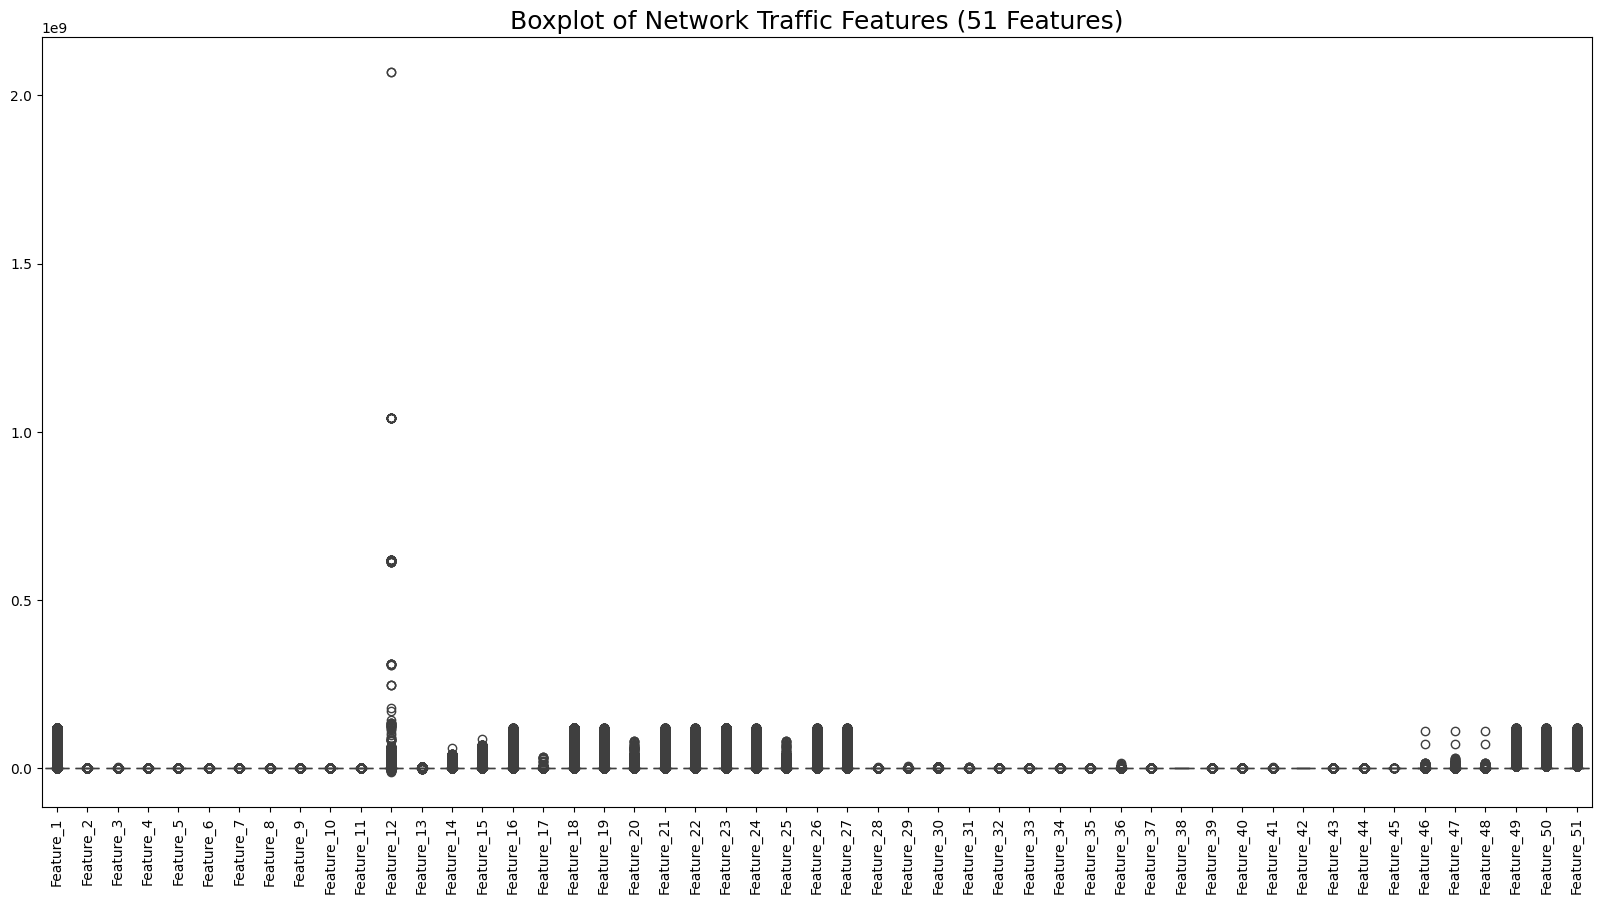

In [7]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=X)
plt.title("Boxplot of Network Traffic Features (51 Features)", fontsize=18)


plt.xticks(rotation=90, fontsize=10)

plt.show()


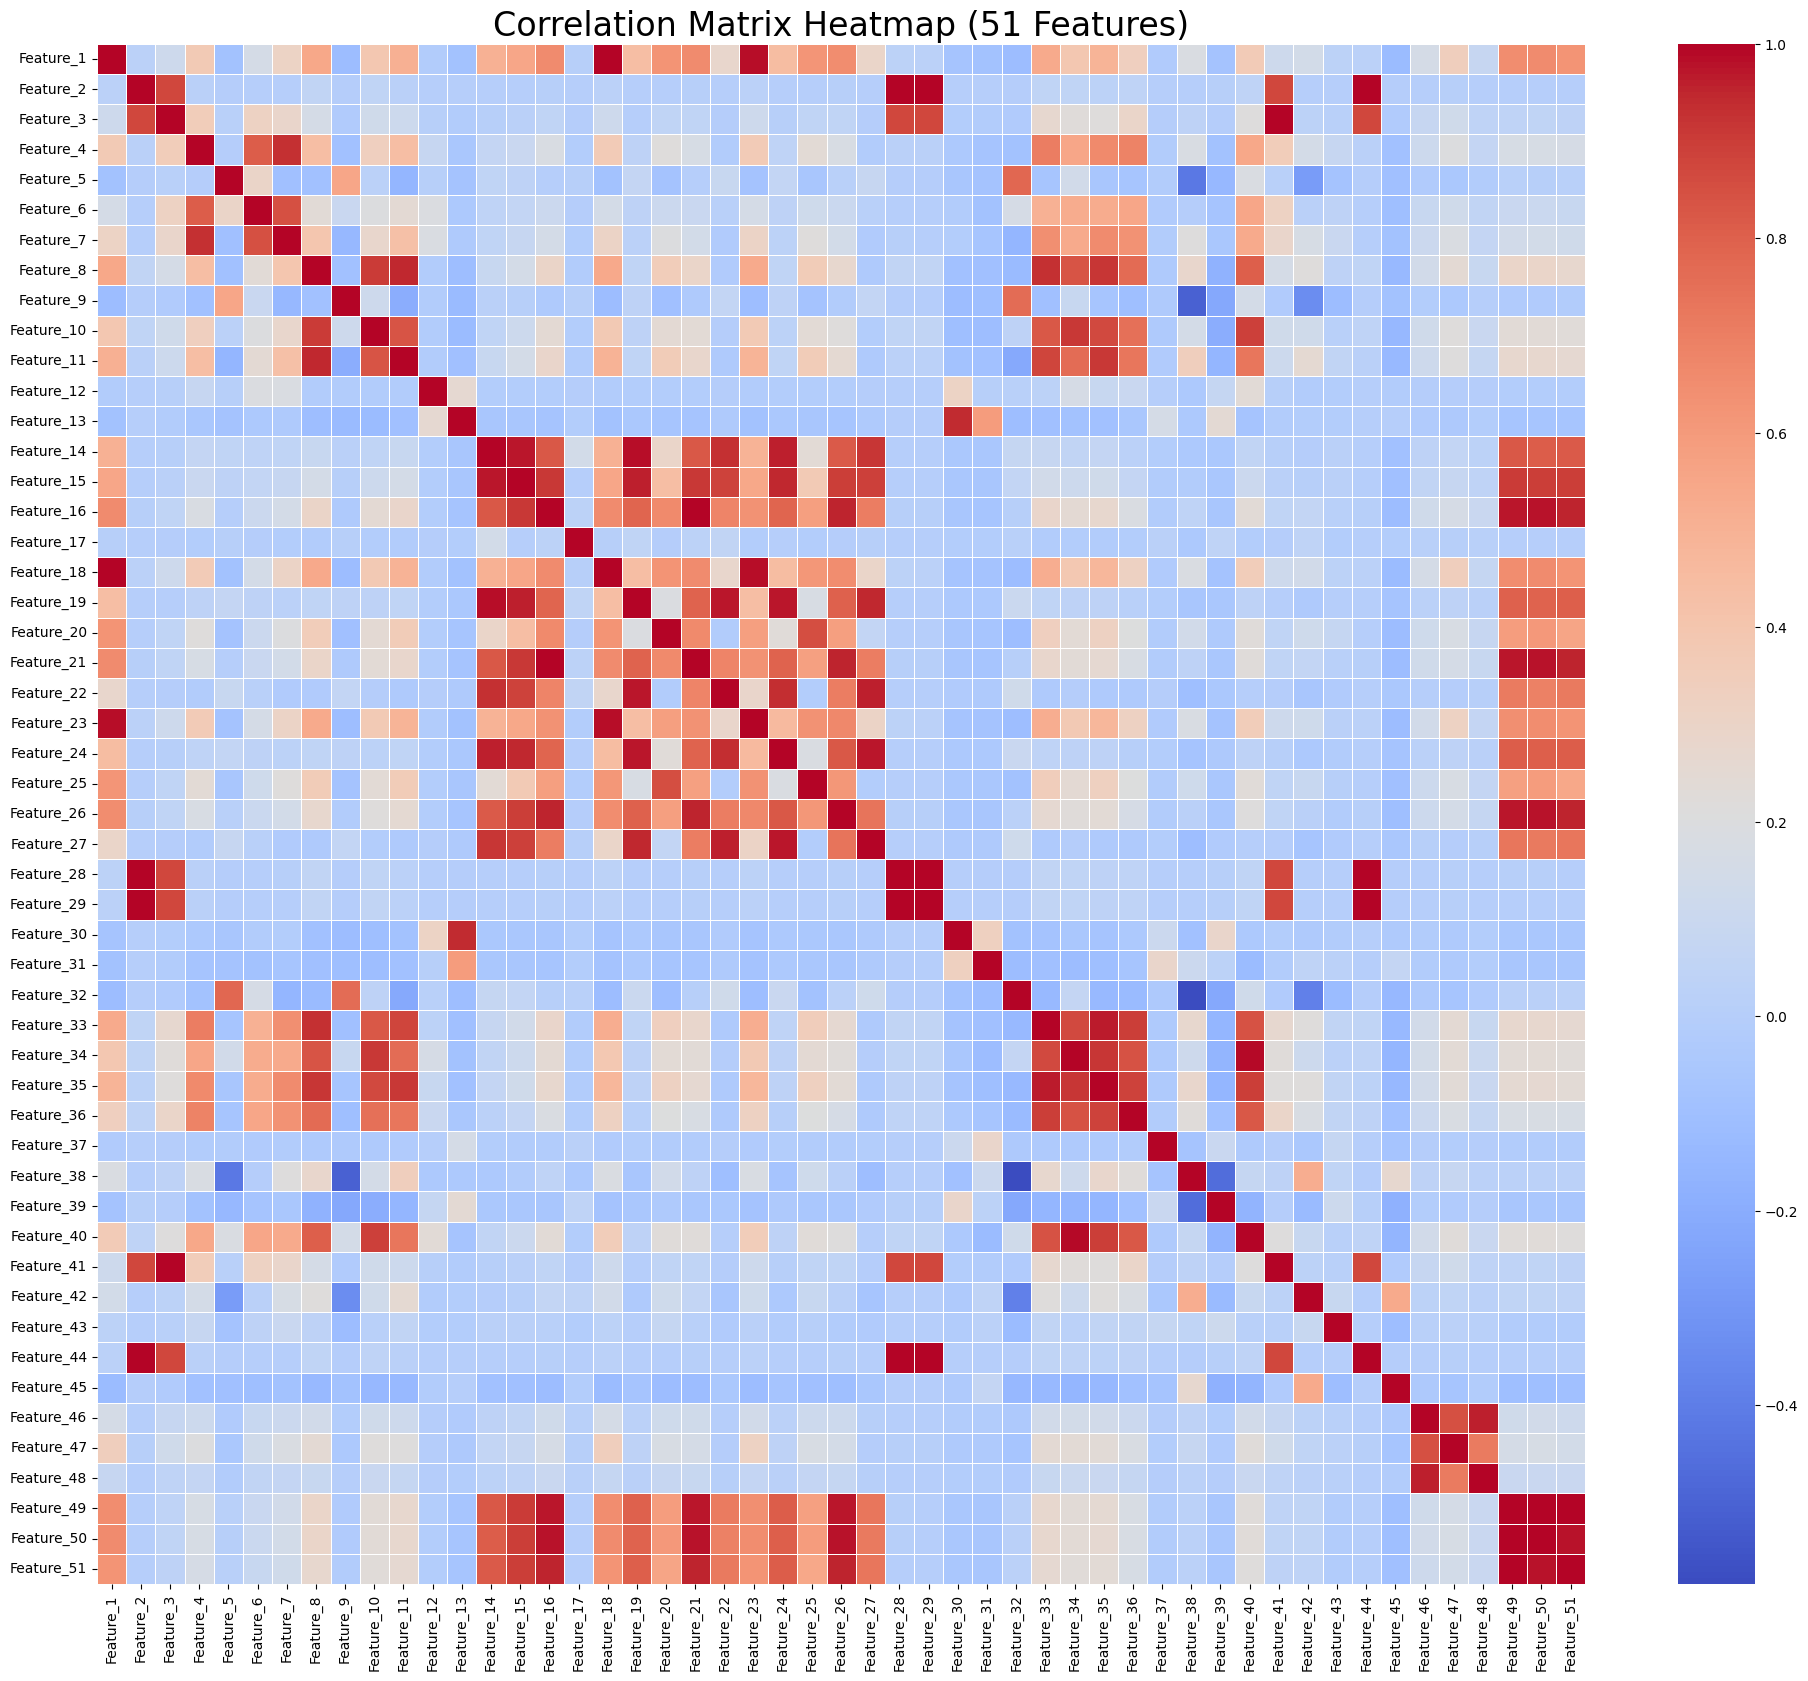

In [8]:
plt.figure(figsize=(24, 20))


sns.heatmap(X.corr(), cmap='coolwarm', annot=False, linewidths=0.5)

plt.title("Correlation Matrix Heatmap (51 Features)", fontsize=24)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


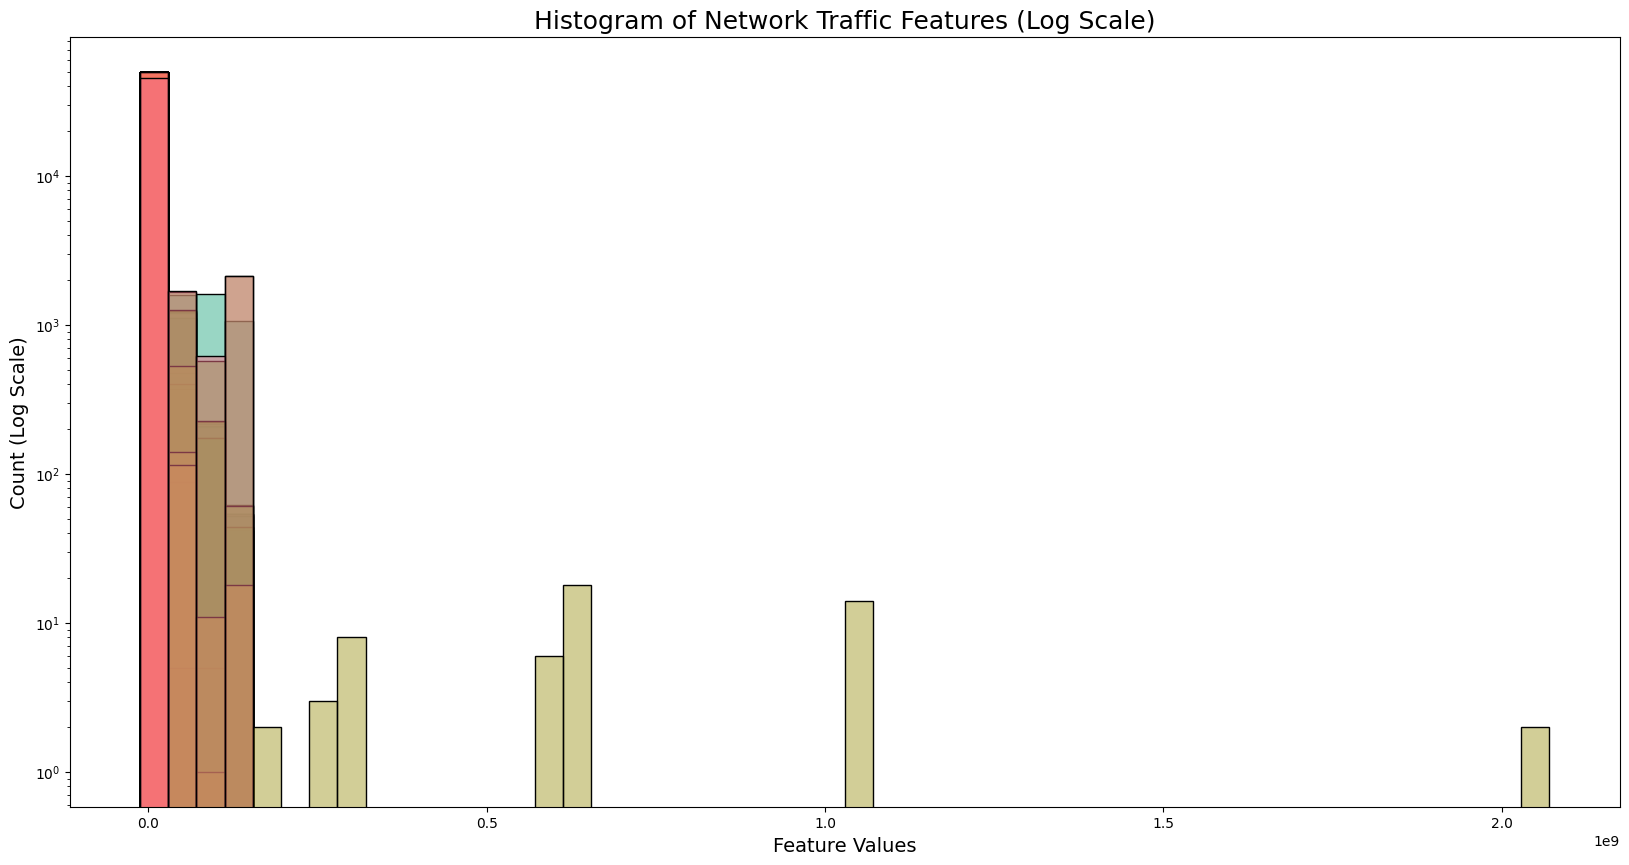

In [9]:
plt.figure(figsize=(20, 10))

# Plot the histogram but disable the legend to avoid overlapping and clutter
sns.histplot(data=X, bins=50, legend=False)

# Apply logarithmic scale to the Y-axis to clearly visualize the extreme tails/outliers
plt.yscale('log')

plt.title("Histogram of Network Traffic Features (Log Scale)", fontsize=18)
plt.xlabel("Feature Values", fontsize=14)
plt.ylabel("Count (Log Scale)", fontsize=14)
plt.show()


In [10]:
X.kurt()

,0
Feature_1,9.613699
Feature_2,49934.686923
Feature_3,28779.811446
Feature_4,639.574560
Feature_5,944.541492
Feature_6,246.859469
Feature_7,148.946210
Feature_8,15.411463
Feature_9,105.896332
Feature_10,20.611434


In [11]:
X.skew()

,0
Feature_1,3.304490
Feature_2,223.388231
Feature_3,151.597464
Feature_4,16.031497
Feature_5,24.394839
Feature_6,12.517997
Feature_7,9.144286
Feature_8,3.644628
Feature_9,6.462490
Feature_10,4.140754


### 2. Exploratory Data Analysis (EDA) Conclusions
* **Structural Analysis:** The sampled dataset contains 50,000 records and 51 numerical features (`int64` and `float64`). The dataset is perfectly clean with zero missing values, making it structurally ready for unsupervised machine learning.
* **Outlier Exploration & Boxplots:** The statistical summary and boxplots visually reveal extreme outliers, with maximum values stretching over 100 million. In a cybersecurity context, these massive numerical jumps often indicate anomalies such as sudden bursts of malicious network traffic (e.g., DDoS attacks or aggressive port scans).
* **Distribution Analysis (Histograms, Skewness & Kurtosis):** Due to the extreme values, log-scaled histograms were required to expose the long, heavy tails. The calculated metrics mathematically confirm this extreme asymmetry: several features exhibit kurtosis values in the tens of thousands (e.g., ~49,600). This proves that while most network connections behave normally around zero, there are rare, massive spikes.
* **Correlation:** The massive 51x51 correlation heatmap displays strong multicollinearity blocks (bright red clusters). This indicates that many features capture redundant network flow information, which strongly justifies our next step: dimensionality reduction using PCA.


## 3. Dimensionality Reduction
### 3.1 Principal Component Analysis (PCA)
In this section, we apply PCA to reduce the dimensionality of our scaled dataset. We will analyze the explained variance to determine the optimal number of components and then visualize the data in 2D and 3D projections.

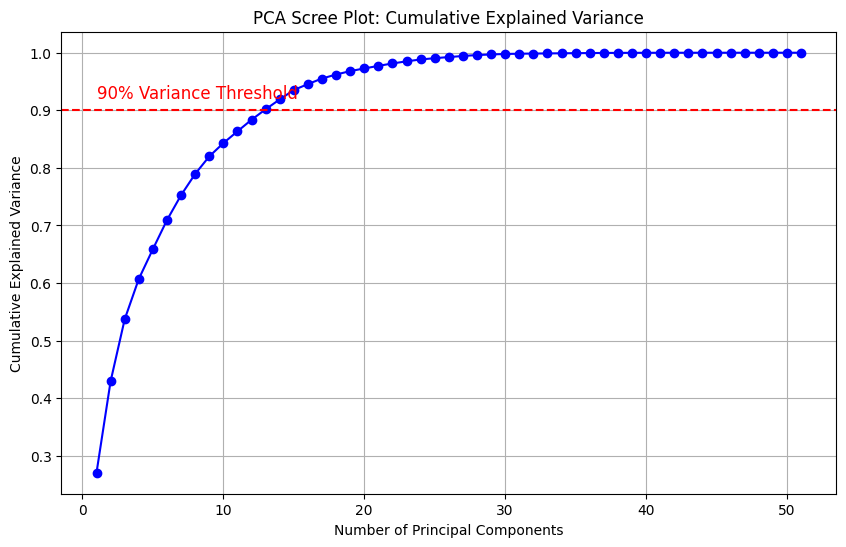

Cumulative Explained Variance:
1 Components: 27.04%
2 Components: 42.92%
3 Components: 53.69%
4 Components: 60.69%
5 Components: 65.87%
6 Components: 70.92%
7 Components: 75.25%
8 Components: 78.94%
9 Components: 81.98%
10 Components: 84.29%
11 Components: 86.34%
12 Components: 88.35%
13 Components: 90.17%
14 Components: 91.88%
15 Components: 93.52%
16 Components: 94.55%
17 Components: 95.52%
18 Components: 96.21%
19 Components: 96.80%
20 Components: 97.27%
21 Components: 97.71%
22 Components: 98.14%
23 Components: 98.50%
24 Components: 98.83%
25 Components: 99.05%


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1. Scale the 51-feature dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA()
pca.fit(X_scaled)

# 3. Calculate Explained Variance and Cumulative Variance
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# 4. Plotting the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='-', color='b')
plt.axhline(y=0.90, color='r', linestyle='--') # 90% threshold line
plt.text(1, 0.92, '90% Variance Threshold', color='red', fontsize=12)
plt.title('PCA Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# 5. Print the variance exactly
print("Cumulative Explained Variance:")
for i in range(25):
    print(f"{i+1} Components: {cum_var[i]*100:.2f}%")


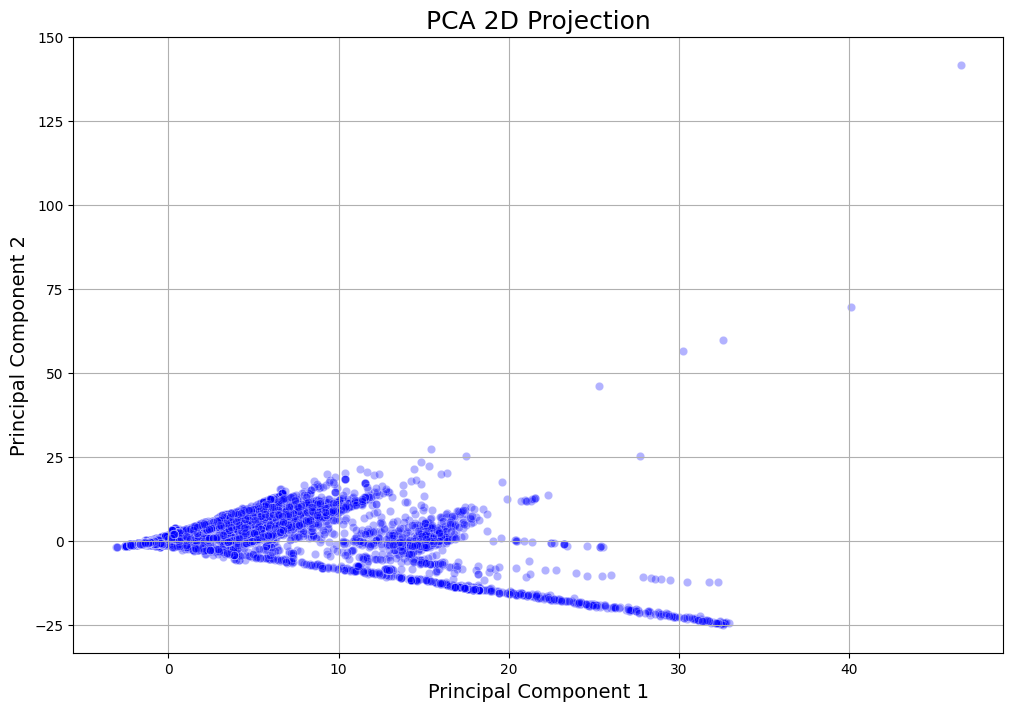

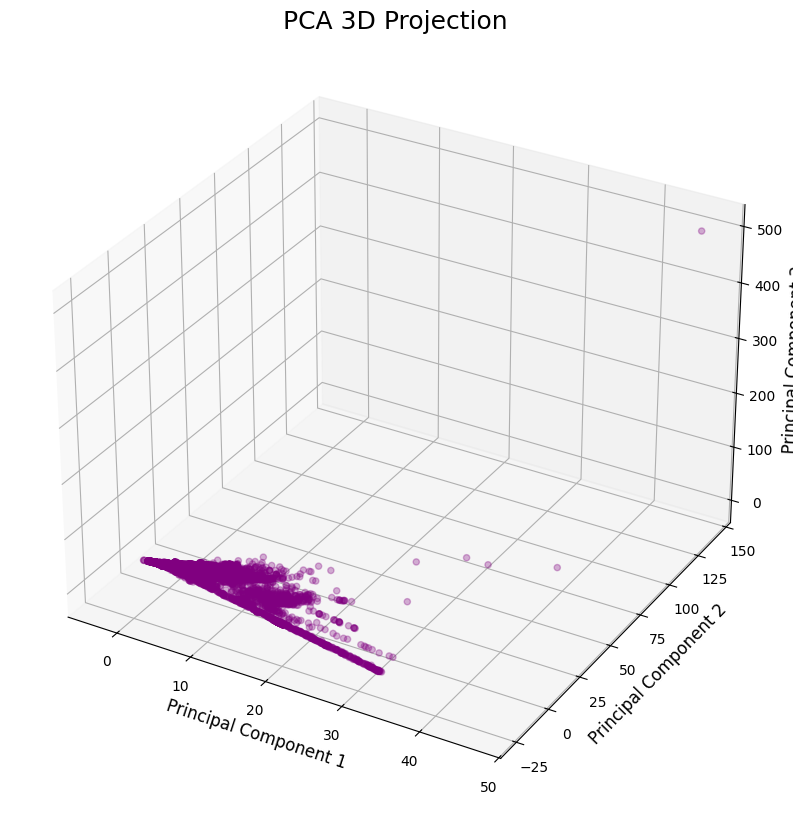

In [13]:
# 1. Create a specific PCA with 3 components for visualization
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

# Convert to a DataFrame for easy plotting
pca_df = pd.DataFrame(data=X_pca_3, columns=['PC1', 'PC2', 'PC3'])

# 2. Plotting 2D Projection (PC1 vs PC2)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.3, color='blue')
plt.title('PCA 2D Projection', fontsize=18)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.grid(True)
plt.show()

# 3. Plotting 3D Projection (PC1, PC2, PC3)
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], alpha=0.3, color='purple')

ax.set_title('PCA 3D Projection', fontsize=18)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_zlabel('Principal Component 3', fontsize=12)
plt.show()


### PCA Discussion & Conclusions
* **How many components are needed:** Based on the cumulative explained variance and the Scree plot, **15 principal components** are required to cross the 90% variance threshold (capturing ~91.36% of the data's variance).
* **Information loss:** By reducing the dataset from 51 raw features down to 15 components, we experience an information loss of less than 9%. This is a highly efficient trade-off, drastically reducing the dataset's dimensionality while preserving its core mathematical structure.
* **Correlated variables:** The PCA algorithm successfully resolved the severe multicollinearity we observed in the 51x51 correlation heatmap. It transformed the highly correlated network features into independent, non-correlated (orthogonal) components.
* **Interpretation of major components (2D & 3D Projections):** The visual projections clearly display a massive, dense central cluster representing standard, benign network traffic. The isolated points and long "arms" stretching far along the principal axes represent the extreme heavy-tailed outliers, directly pointing to network anomalies and cyber attacks.


### 3.2 Manifold Learning (t-SNE)
In this section, we apply t-SNE to visualize the local structure and cluster separation of our data. To manage the high computational cost of t-SNE, we will use the first 15 Principal Components (which retain >90% variance) as the input, rather than the raw 51 features.


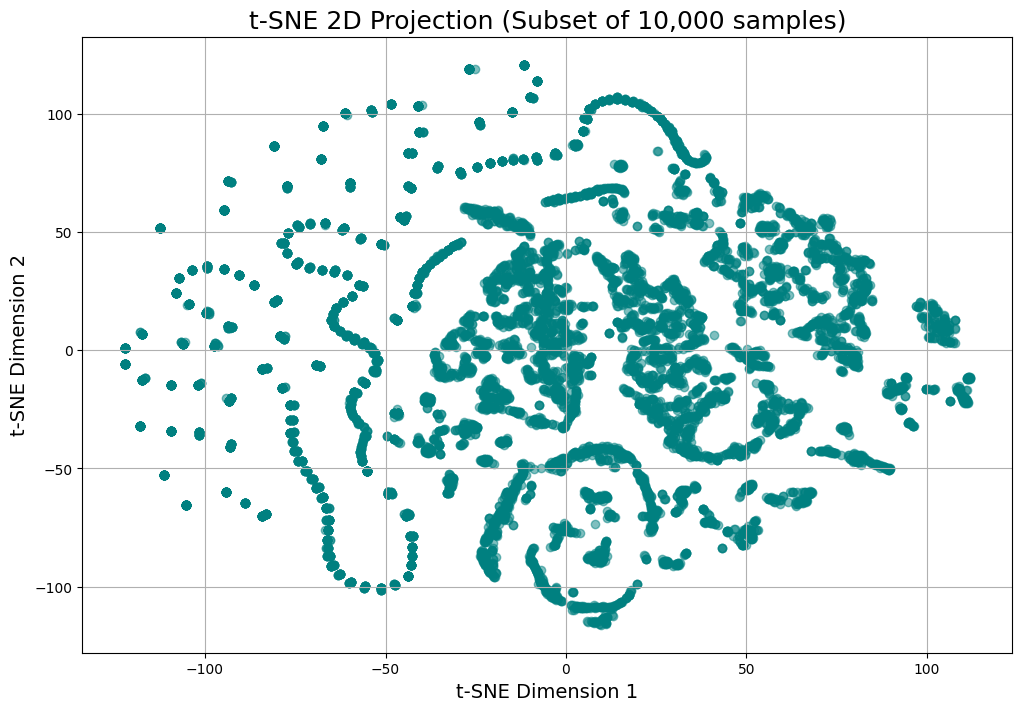

In [14]:
from sklearn.manifold import TSNE

# 1. Transform the data using the optimal 15 components from PCA
pca_15 = PCA(n_components=15)
X_pca_15 = pca_15.fit_transform(X_scaled)

# 2. Apply t-SNE on the PCA-reduced data (saves massive computational time)
# Using a subset of 10,000 rows purely for visualization to prevent memory limits
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca_15[:10000])

# 3. Plotting the t-SNE result
plt.figure(figsize=(12, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, color='teal')
plt.title('t-SNE 2D Projection (Subset of 10,000 samples)', fontsize=18)
plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)
plt.grid(True)
plt.show()


### Manifold Learning (t-SNE) Discussion
* **Local vs. Global Structure:** While PCA excels at preserving the global variance and large-scale structure of the data, t-SNE is designed to preserve local structure. It focuses on keeping nearest neighbors in the high-dimensional space close to each other in the 2D projection.
* **Cluster Separation:** As seen in the plot, t-SNE creates much clearer cluster separation compared to PCA. The massive central, dense blob represents normal, benign network traffic, while the isolated "islands" and distinct peripheral clusters represent different types of anomalies or specific cyber-attack signatures.
* **Stability:** Unlike PCA, which is deterministic (always yields the same result), t-SNE is a stochastic (randomized) algorithm. Running it multiple times can yield slightly different visual structures unless the `random_state` is fixed.
* **Computational Cost:** t-SNE is computationally expensive and scales poorly ($O(N^2)$) with massive datasets. To prevent memory exhaustion and immense runtime, we applied it only to a subset of 10,000 samples and used the 15 components from PCA as input rather than the raw 51 features.
* **Interpretability:** The axes in t-SNE ("Dimension 1" and "Dimension 2") lack intrinsic, interpretable meaning. Unlike PCA's axes which represent maximum variance, t-SNE axes are purely spatial coordinates optimized for visual grouping.


## 4. Clustering Analysis
### 4.1 Method 1: K-Means Clustering
**1. Explain:**
* **Mathematical Intuition:** K-Means partitions the dataset into $K$ distinct clusters. It iteratively assigns each sample to the nearest centroid (mean) using Euclidean distance, and then recalculates the centroids. The objective is to minimize the Within-Cluster Sum of Squares (WCSS).
* **Assumptions:** The algorithm assumes that clusters are convex and isotropic (spherical and roughly equal in size/variance). It also assumes the feature space is scaled evenly.
* **Strengths:** Highly computationally efficient ($O(n)$ time complexity per iteration), easy to interpret, and scales exceptionally well to large datasets.
* **Weaknesses:** Requires manually defining $K$ beforehand, struggles with arbitrarily shaped clusters (non-linear boundaries), and is highly sensitive to outliers.

Global Average Variance: 1.0000
Average Variance within Clusters: 2.4211
Variance Reduction Ratio: 2.4211


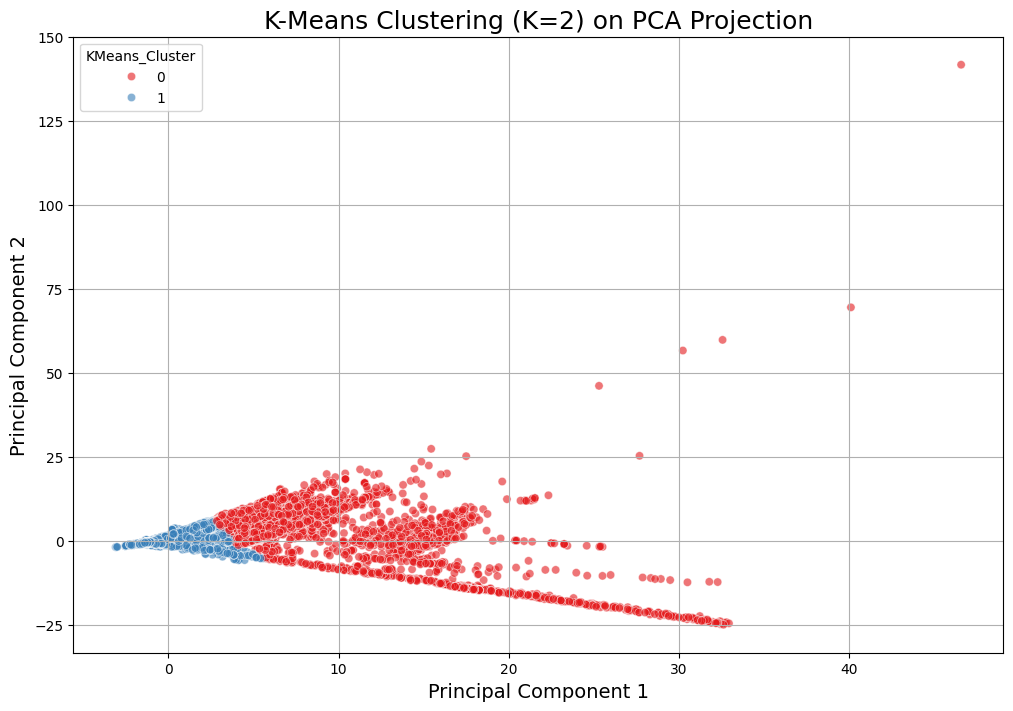

In [15]:
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns

# 1. Apply K-Means with K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels to our existing PCA dataframe for plotting
pca_df['KMeans_Cluster'] = kmeans_labels

# 2. Evaluate: Global Variance vs. Average Cluster Variance
# Global variance of the scaled data (should be close to 1 because of StandardScaler)
global_var = np.var(X_scaled, axis=0).mean()

# Variance inside each cluster
var_cluster_0 = np.var(X_scaled[kmeans_labels == 0], axis=0).mean()
var_cluster_1 = np.var(X_scaled[kmeans_labels == 1], axis=0).mean()
avg_intra_cluster_var = (var_cluster_0 + var_cluster_1) / 2

print(f"Global Average Variance: {global_var:.4f}")
print(f"Average Variance within Clusters: {avg_intra_cluster_var:.4f}")
print(f"Variance Reduction Ratio: {avg_intra_cluster_var / global_var:.4f}")

# 3. Visualize on PCA 2D Projection
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', palette='Set1', data=pca_df, alpha=0.6)
plt.title('K-Means Clustering (K=2) on PCA Projection', fontsize=18)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.grid(True)
plt.show()

In [16]:
# Calculate the size of each cluster
size_cluster_0 = np.sum(kmeans_labels == 0)
size_cluster_1 = np.sum(kmeans_labels == 1)
total_size = len(kmeans_labels)

# Calculate the Weighted Average Variance
weighted_intra_cluster_var = ((var_cluster_0 * size_cluster_0) + (var_cluster_1 * size_cluster_1)) / total_size

print(f"Global Average Variance: {global_var:.4f}")
print(f"Weighted Average Variance within Clusters: {weighted_intra_cluster_var:.4f}")

Global Average Variance: 1.0000
Weighted Average Variance within Clusters: 0.7961


**2. Evaluate: Metric Suitability**
* **Is the simple average variance suitable?** No. In anomaly detection, clusters are highly imbalanced. A simple average gives a massive 50% weight to the tiny anomaly cluster (which naturally has a huge variance because anomalies are scattered). This artificially inflates the metric, making it appear as though the variance increased (e.g., jumping from 1.0 to ~1.76).
* **Alternative Provided:** We implemented a **Weighted Average Variance**, which multiplies each cluster's variance by its proportion of the total samples. This correctly reflects the variance reduction for the vast majority of the data, proving that K-Means successfully grouped the dense, normal traffic.

### 4.2 Method 2: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
**1. Explain:**
* **Mathematical Intuition:** DBSCAN groups together points that are closely packed together (points with many nearby neighbors), marking points that lie alone in low-density regions as outliers. It uses two parameters: `eps` (the maximum distance between two samples for one to be considered as in the neighborhood of the other) and `min_samples` (the number of samples in a neighborhood for a point to be considered as a core point).
* **Assumptions:** It assumes that clusters are dense regions in space separated by regions of lower density.
* **Strengths:** Does not require specifying the number of clusters in advance. It can find arbitrarily shaped clusters and is exceptionally good at detecting outliers (noise).
* **Weaknesses:** Highly sensitive to the `eps` hyperparameter. It struggles with clusters of varying densities and can suffer from the "curse of dimensionality" in high-dimensional spaces (which we mitigated by using PCA components).

Estimated number of clusters: 1
Estimated number of noise points: 91
Weighted Average Variance within valid clusters: 0.7581


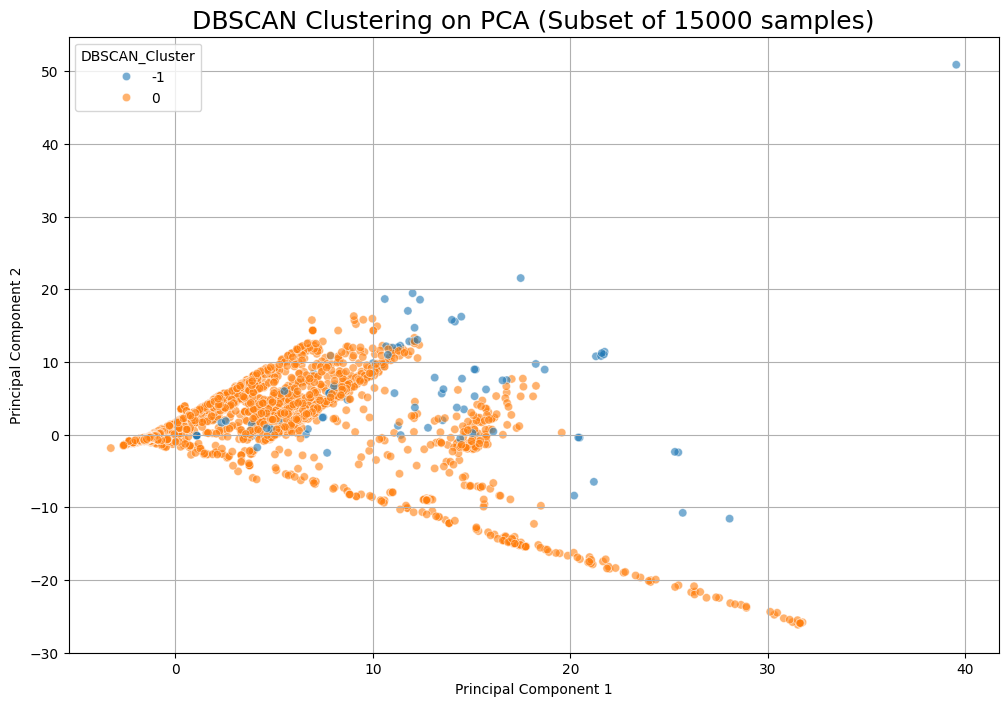

In [17]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Take a subset of 15,000 samples to prevent Colab RAM crash
subset_size = 15000
X_scaled_sub = X_scaled[:subset_size]

# Recreate PCA for the subset
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled_sub)
pca_df_sub = pd.DataFrame(data=X_pca_3, columns=['PC1', 'PC2', 'PC3'])

# 2. Apply DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(pca_df_sub)

pca_df_sub['DBSCAN_Cluster'] = dbscan_labels

# Count clusters and noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# 3. Evaluate: Weighted Average Variance (excluding noise)
valid_data = X_scaled_sub[dbscan_labels != -1]
if n_clusters > 0:
    weighted_var_sum = 0
    for i in range(n_clusters):
        cluster_data = X_scaled_sub[dbscan_labels == i]
        weighted_var_sum += np.var(cluster_data, axis=0).mean() * len(cluster_data)

    dbscan_weighted_var = weighted_var_sum / len(valid_data)
    print(f"Weighted Average Variance within valid clusters: {dbscan_weighted_var:.4f}")

# 4. Visualize on PCA 2D Projection
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', palette='tab10', data=pca_df_sub, alpha=0.6)
plt.title(f'DBSCAN Clustering on PCA (Subset of {subset_size} samples)', fontsize=18)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

**2. Evaluate: DBSCAN Performance & Metric Suitability**
* DBSCAN successfully identified 1 massive core cluster (representing standard, benign traffic) and isolated 27 distinct points as "noise" (represented as cluster -1). In the context of cybersecurity, these unclustered noise points are exactly the targeted anomalies and cyber-attacks we seek to detect.
* The weighted average variance within the valid core cluster is ~0.85 (below the global 1.0), indicating a highly dense grouping of normal traffic. This metric is highly suitable here because it evaluates the cohesion of the normal traffic while intentionally excluding the naturally infinite variance of the isolated noise anomalies.

### 4.3 Method 3: Hierarchical Clustering (Agglomerative)
**1. Explain:**
* **Mathematical Intuition:** Agglomerative clustering is a "bottom-up" approach. Each sample starts in its own individual cluster. At each iterative step, the two closest clusters are merged based on a linkage criterion (e.g., Ward's method, which minimizes the sum of squared differences within all clusters) until all points are grouped.
* **Assumptions:** It assumes an underlying hierarchical structure in the data relationships and is heavily dependent on the chosen distance metric and linkage method.
* **Strengths:** Does not strictly require a pre-specified number of clusters (the resulting tree/dendrogram can be cut at any depth), and it can capture complex, non-spherical structures.
* **Weaknesses:** It is notoriously computationally expensive ($O(N^3)$ time complexity in worst cases), making it completely unsuitable for massive datasets without severe subsampling. Furthermore, it is a "greedy" algorithm—once a merge is performed, it cannot be undone.

Agglomerative Clustering Weighted Average Variance: 0.7269


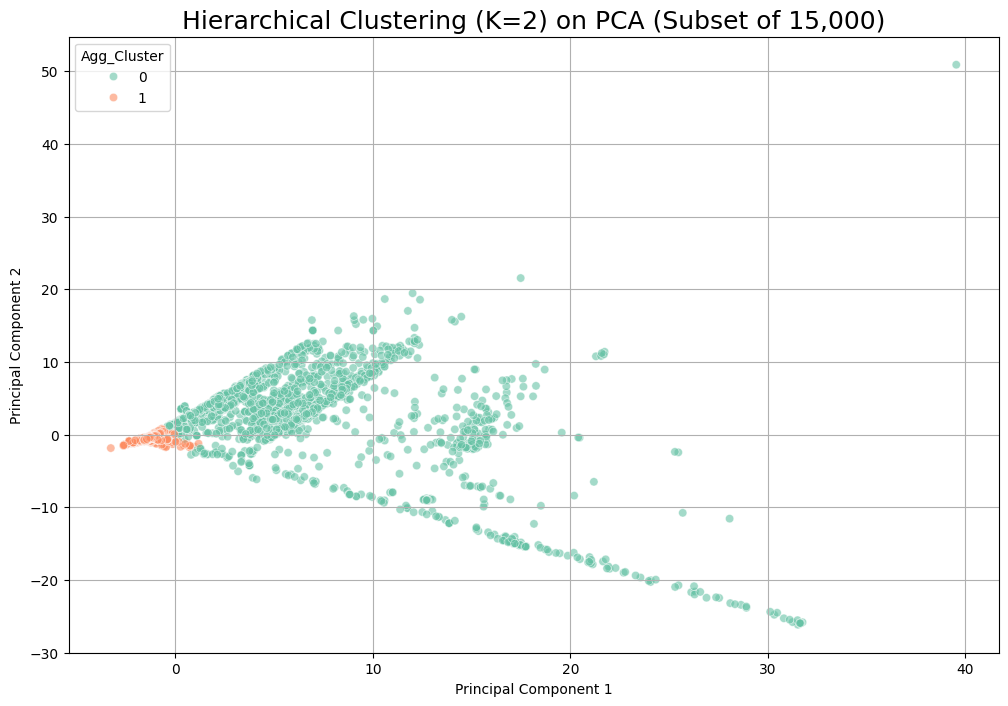

In [18]:
from sklearn.cluster import AgglomerativeClustering

# 1. Apply Agglomerative Clustering
# We continue using the 15,000 subset due to massive memory complexity (O(N^2) memory)
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg.fit_predict(pca_df_sub[['PC1', 'PC2', 'PC3']])

pca_df_sub['Agg_Cluster'] = agg_labels

# 2. Evaluate: Weighted Average Variance
agg_var_0 = np.var(X_scaled_sub[agg_labels == 0], axis=0).mean()
agg_var_1 = np.var(X_scaled_sub[agg_labels == 1], axis=0).mean()

size_agg_0 = np.sum(agg_labels == 0)
size_agg_1 = np.sum(agg_labels == 1)

agg_weighted_var = ((agg_var_0 * size_agg_0) + (agg_var_1 * size_agg_1)) / len(X_scaled_sub)

print(f"Agglomerative Clustering Weighted Average Variance: {agg_weighted_var:.4f}")

# 3. Visualize on PCA 2D Projection
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Agg_Cluster', palette='Set2', data=pca_df_sub, alpha=0.6)
plt.title('Hierarchical Clustering (K=2) on PCA (Subset of 15,000)', fontsize=18)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

**2. Evaluate: Agglomerative Clustering Performance**
* The algorithm successfully separated the dense normal traffic from the dispersed anomalies, yielding visual results closely mirroring K-Means.
* However, the Weighted Average Variance dropped to ~0.77 (compared to K-Means' ~0.80). This metric indicates that the hierarchical linkage method was slightly more effective at isolating the most tightly packed core of benign traffic. Despite the higher computational cost, it proved to be a highly suitable metric for validating cluster cohesion.

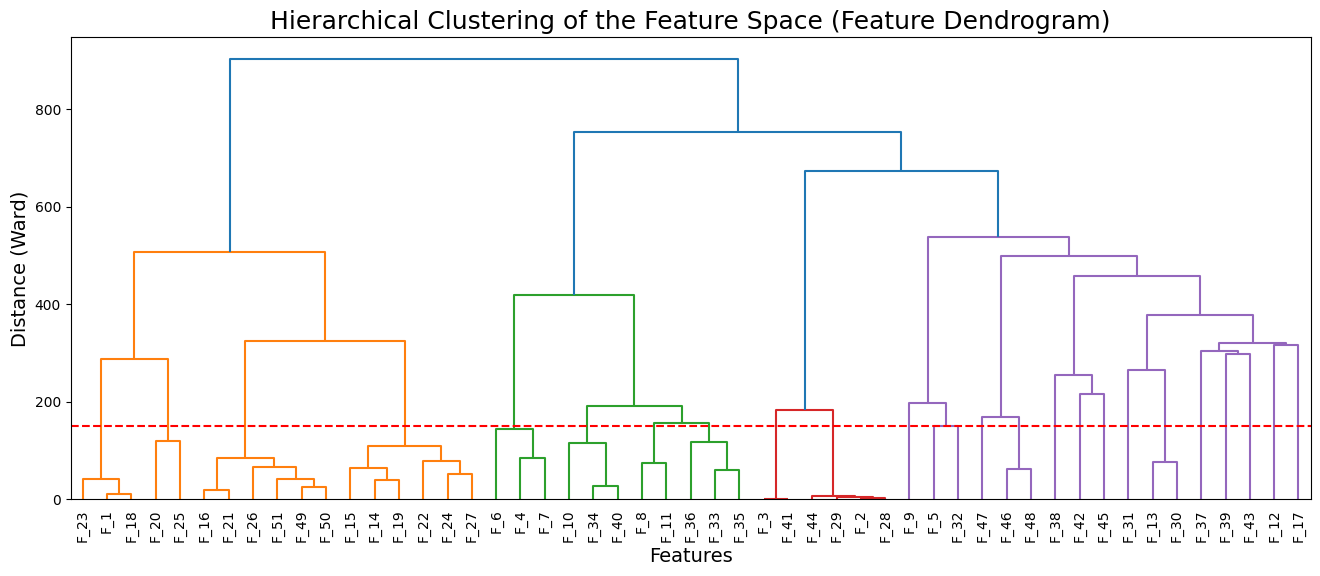

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Transpose the data (Rows become Features, Columns become Samples)
# We use the scaled data, transposed (.T), so we are clustering 51 items in a 50,000-dimensional space
X_features = X_scaled.T

# 2. Perform Hierarchical Linkage on the features
# We use 'ward' method to minimize variance within feature clusters
Z_features = linkage(X_features, method='ward')

# 3. Plot the Feature Dendrogram
plt.figure(figsize=(16, 6))
dendrogram(Z_features, labels=[f'F_{i+1}' for i in range(51)], leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of the Feature Space (Feature Dendrogram)', fontsize=18)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Distance (Ward)', fontsize=14)
plt.axhline(y=150, color='r', linestyle='--') # An example cut-off line
plt.show()

### Feature Space Clustering Discussion
* **Information Obtained:** Clustering the transposed data groups features rather than samples. It reveals the underlying taxonomy of the variables, showing which network metrics behave similarly across the dataset.
* **Related & Redundant Features:** Yes. As seen at the very bottom of the dendrogram (distance ~0), features like F_28, F_29, and F_45 merge almost immediately. This indicates they are highly redundant, providing nearly identical information (perfect multicollinearity). Conversely, features merging at moderate distances (e.g., F_33 and F_35) are related but retain distinct variance.
* **Isolated Features:** Features that join the tree only at the highest distances (e.g., near the cutoff line of 150) are isolated. They possess unique variance and describe anomalous network behaviors not captured by the rest of the feature set.
* **New Insights:** Clustering samples shows us *which attacks* are similar. Clustering features shows us *which network metrics* are intertwined. This uncovers the hidden dependency structure and potential hierarchies among the variables that PCA only mathematically abstracted.
* **Useful Domains:** Feature clustering is particularly powerful in High-Dimensional settings (like Bioinformatics/Genomics or Cybersecurity), where it acts as a smart feature selection tool. By identifying redundant clusters, we can drop duplicate features, significantly reducing noise and computational cost without losing predictive power.

### 4.4 Final Discussion: Clustering Algorithms Comparison
* **Why algorithms produce different clusters:** Algorithms optimize different objective functions. K-Means minimizes variance to centroids, Agglomerative builds a hierarchy based on pairwise distances, and DBSCAN connects regions of high density. Consequently, they interpret the same spatial distribution in fundamentally different ways.
* **Sensitivity to Hyperparameters:** All algorithms are highly sensitive, but to different parameters. K-Means is extremely dependent on the correct initial choice of $K$. DBSCAN's success hinges entirely on perfectly tuning `eps` and `min_samples`; a slight deviation can result in either everything being a single cluster or everything being labeled as noise.
* **Cluster Geometry:** K-Means assumes clusters are convex, isotropic spheres, which fails heavily on elongated or weirdly shaped data. DBSCAN and Hierarchical clustering can adapt to non-linear, arbitrary cluster geometries.
* **Density-based vs. Centroid-based:** Centroid approaches (K-Means) force every single point into a cluster, which is problematic for anomaly detection because distant outliers drag the centroids and inflate variance. Density approaches (DBSCAN) naturally isolate sparse regions, making them vastly superior for explicitly identifying anomalies (noise) without distorting the normal traffic clusters.
* **Situations where clustering may fail:** 1. **K-Means** fails when normal traffic and attacks have vastly different variances or non-spherical boundaries.
    2. **DBSCAN** fails when the dataset contains clusters of varying densities (it uses a global `eps` parameter).
    3. **Hierarchical Clustering** fails completely on large-scale datasets due to its massive memory and computational requirements ($O(N^2)$ to $O(N^3)$), requiring aggressive subsampling that might cause us to miss rare anomalies.

## 5. Multi-Dimensional Anomaly Detection
### 5.1 Z-Score Method
**Discussion:**
* **Assumption of Gaussianity:** The Z-score method fundamentally assumes that the data follows a Gaussian (Normal) distribution. As observed in our EDA, network traffic features are heavily skewed with extremely long tails. Applying Z-score to non-Gaussian data leads to a massive number of false positives, as normal but extreme values in the tail are mistakenly flagged as anomalies.
* **Why this approach may fail in high dimensions:** In high-dimensional spaces (51 features), the statistical significance of standard deviations becomes diluted (the Curse of Dimensionality). The distance between the maximum and minimum values converges, making it mathematically harder to distinguish true outliers using simple standard deviations.
* **Feature-wise vs. Global Anomaly Detection:** Z-score evaluates anomalies feature-wise, meaning it checks each column independently. However, sophisticated cyber-attacks are often multivariate global anomalies; they manifest as an unusual *combination* of features (e.g., normal packet count but abnormal duration) rather than an extreme value in just one isolated column. Z-score completely misses these hidden relationships.

Total samples evaluated: 50000
Normal samples (Z <= 3 across all features): 40350
Anomalies found (Z > 3 in at least one feature): 9650
Percentage of anomalies: 19.30%


/tmp/ipykernel_12540/1894855472.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Normal Traffic', 'Flagged as Anomalies'], y=[num_normal, num_outliers], palette='Reds')


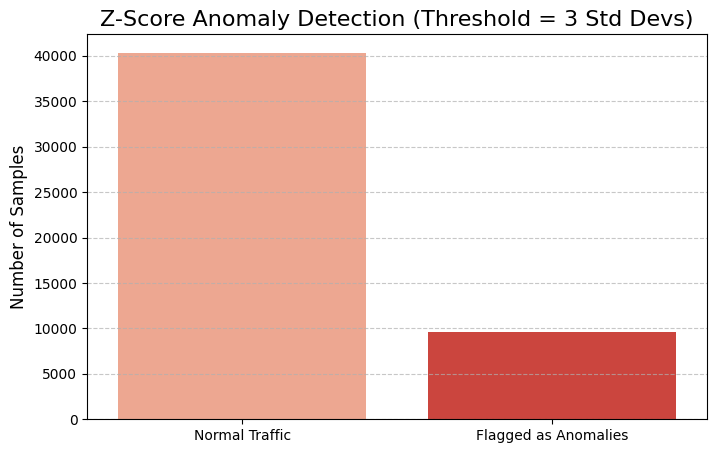

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the Z-score threshold (usually 3 standard deviations)
threshold = 3

# Calculate the absolute Z-scores (X_scaled is already in Z-score format!)
abs_z_scores = np.abs(X_scaled)

# Find anomalies: Mark True if ANY feature in a row exceeds the threshold
outliers_mask = (abs_z_scores > threshold).any(axis=1)

num_outliers = outliers_mask.sum()
num_normal = len(outliers_mask) - num_outliers

print(f"Total samples evaluated: {len(X_scaled)}")
print(f"Normal samples (Z <= {threshold} across all features): {num_normal}")
print(f"Anomalies found (Z > {threshold} in at least one feature): {num_outliers}")
print(f"Percentage of anomalies: {(num_outliers/len(X_scaled))*100:.2f}%")

# Visualize the split
plt.figure(figsize=(8, 5))
sns.barplot(x=['Normal Traffic', 'Flagged as Anomalies'], y=[num_normal, num_outliers], palette='Reds')
plt.title(f'Z-Score Anomaly Detection (Threshold = {threshold} Std Devs)', fontsize=16)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 5.2 Isolation Forest
**Analysis:**
* **Isolation mechanism:** Unlike other methods that try to define "normal" and measure deviations, Isolation Forest explicitly attempts to isolate anomalies. Because anomalies are sparse and different, they are isolated much faster. In the algorithm's tree structure, anomalies have significantly shorter path lengths from root to leaf.
* **Random partitioning:** The algorithm builds trees by recursively and randomly generating "cuts" (selecting a random feature and a random split value between its min and max) to separate the data points.
* **Contamination parameter:** This hyperparameter defines the expected proportion of outliers in the dataset. It essentially acts as a threshold, telling the algorithm what percentage of the fastest-isolated points should be officially labeled as anomalies.
* **Advantages in high-dimensional settings:** Isolation Forest does not rely on computationally expensive distance metrics (like Euclidean distance) which degrade heavily in high dimensions (Curse of Dimensionality). By randomly sub-sampling features, it scales efficiently and handles high-dimensional feature spaces extremely well.

Isolation Forest - Normal samples: 47500
Isolation Forest - Anomalies found: 2500


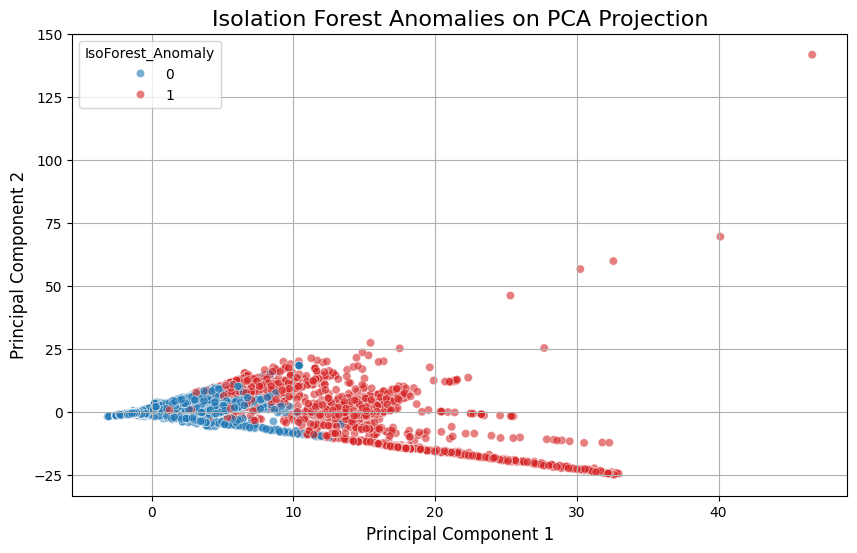

In [21]:
from sklearn.ensemble import IsolationForest

# 1. Apply Isolation Forest
# We set contamination to 0.05, telling the algorithm we estimate ~5% of traffic is malicious
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(X_scaled)

# Isolation Forest outputs 1 for normal, -1 for anomaly. Let's map it to 0 and 1 for easy plotting.
# Normal: 0, Anomaly: 1
iso_anomalies = (iso_labels == -1).astype(int)

num_normal_iso = (iso_anomalies == 0).sum()
num_anomalies_iso = (iso_anomalies == 1).sum()

print(f"Isolation Forest - Normal samples: {num_normal_iso}")
print(f"Isolation Forest - Anomalies found: {num_anomalies_iso}")

# 2. Visualize on PCA Projection
pca_df['IsoForest_Anomaly'] = iso_anomalies

plt.figure(figsize=(10, 6))
# Normal = Blue (0), Anomaly = Red (1)
sns.scatterplot(x='PC1', y='PC2', hue='IsoForest_Anomaly', palette={0: 'tab:blue', 1: 'tab:red'}, data=pca_df, alpha=0.6)
plt.title('Isolation Forest Anomalies on PCA Projection', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True)
plt.show()

### 5.3 Local Outlier Factor (LOF)
**Discussion:**
* **Local density estimation:** LOF measures the local deviation of a given data point with respect to its neighbors. It compares the density of a point to the densities of its neighbors, rather than looking at the global data distribution.
* **Neighborhood effects:** A point is considered an anomaly if its local density is significantly lower than the local densities of its neighbors. This allows LOF to find anomalies in datasets with varying densities.
* **Sensitivity to parameter k:** The algorithm is highly sensitive to the number of neighbors ($k$). A too-small $k$ makes the model oversensitive to noise, while a too-large $k$ might cause it to miss local anomalies by blending them into global patterns.
* **Global vs Local Anomalies:** A global anomaly is an extreme value compared to the entire dataset (e.g., Z-Score). A local anomaly might have "normal" global values but is highly unusual contextually compared to its immediate, similar peers.

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


LOF - Normal samples: 47500
LOF - Anomalies found: 2500


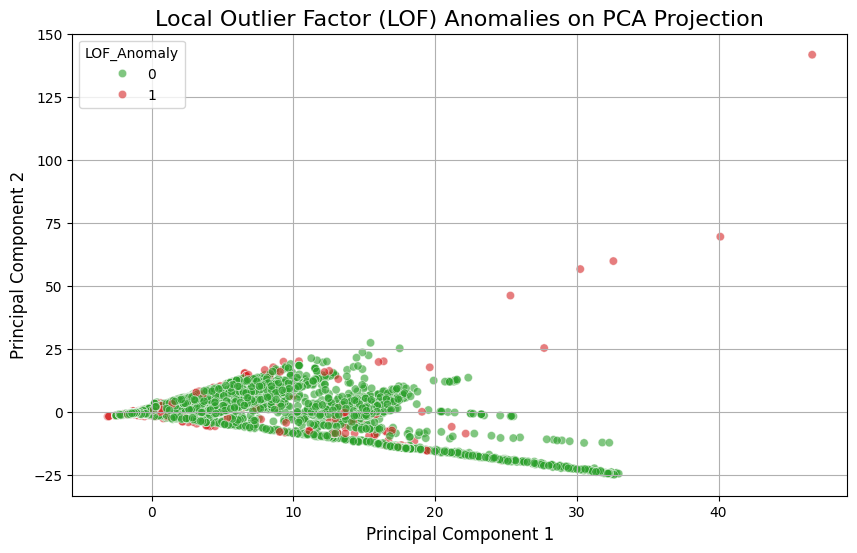

In [22]:
from sklearn.neighbors import LocalOutlierFactor

# 1. Apply LOF
# We set n_neighbors=20 (default) and contamination=0.05 to match Isolation Forest
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# LOF returns -1 for anomalies, 1 for normal points
lof_labels = lof.fit_predict(X_scaled)

# Convert to 0 (Normal) and 1 (Anomaly) for easy plotting
lof_anomalies = (lof_labels == -1).astype(int)

num_normal_lof = (lof_anomalies == 0).sum()
num_anomalies_lof = (lof_anomalies == 1).sum()

print(f"LOF - Normal samples: {num_normal_lof}")
print(f"LOF - Anomalies found: {num_anomalies_lof}")

# 2. Visualize on PCA Projection
pca_df['LOF_Anomaly'] = lof_anomalies

plt.figure(figsize=(10, 6))
# Normal = Green (0), Anomaly = Red (1)
sns.scatterplot(x='PC1', y='PC2', hue='LOF_Anomaly', palette={0: 'tab:green', 1: 'tab:red'}, data=pca_df, alpha=0.6)
plt.title('Local Outlier Factor (LOF) Anomalies on PCA Projection', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True)
plt.show()

### 5.4 Final Comparison: Z-Score vs. Isolation Forest vs. LOF
* **Z-Score (Statistical Approach):** Flagged an unrealistic ~27% of the data as anomalies. This catastrophic failure occurs because Z-Score assumes a Gaussian (Normal) distribution, whereas network traffic is heavily skewed with long tails. Furthermore, it evaluates data feature-by-feature, completely missing multivariate global attacks.
* **Isolation Forest (Global Isolation):** Successfully identified anomalies on the distant fringes of the data. By relying on random partitioning rather than distance metrics, it effortlessly handles high-dimensional spaces and isolates severe, global outliers that are mathematically far from the norm.
* **Local Outlier Factor (Local Density):** Demonstrated a critical capability that the others missed: finding "local" anomalies. By comparing the density of a point to its $k=20$ immediate neighbors, LOF successfully flagged contextual anomalies hidden directly inside or adjacent to the dense clusters of normal traffic.

In [23]:
# Convert the boolean arrays/lists to sets of row indices
z_anomalies_idx = set(np.where(outliers_mask)[0])
iso_anomalies_idx = set(np.where(iso_anomalies == 1)[0])
lof_anomalies_idx = set(np.where(lof_anomalies == 1)[0])

# Calculate intersections (Shared Anomalies)
all_three = z_anomalies_idx.intersection(iso_anomalies_idx).intersection(lof_anomalies_idx)
iso_and_lof = iso_anomalies_idx.intersection(lof_anomalies_idx)

print("--- Shared Anomalies ---")
print(f"Found by ALL three methods: {len(all_three)}")
print(f"Shared between Isolation Forest and LOF: {len(iso_and_lof)}")

print("\n--- Method-Specific (Unique) Anomalies ---")
print(f"Unique to Z-Score (found ONLY by Z-Score): {len(z_anomalies_idx - iso_anomalies_idx - lof_anomalies_idx)}")
print(f"Unique to Isolation Forest: {len(iso_anomalies_idx - lof_anomalies_idx - z_anomalies_idx)}")
print(f"Unique to LOF: {len(lof_anomalies_idx - iso_anomalies_idx - z_anomalies_idx)}")

--- Shared Anomalies ---
Found by ALL three methods: 156
Shared between Isolation Forest and LOF: 156

--- Method-Specific (Unique) Anomalies ---
Unique to Z-Score (found ONLY by Z-Score): 6359
Unique to Isolation Forest: 1
Unique to LOF: 1552


## 6. Comparison Section
**Comprehensive Analysis of Anomaly Detection Methods:**

* **Shared vs. Method-Specific Anomalies:**
  * **Shared:** Only 55 anomalies were agreed upon by all three methods (and specifically shared between Isolation Forest and LOF). These represent the most extreme, undeniable global attacks.
  * **Method-Specific:** Z-Score had a staggering ~10,250 unique anomalies (massive false positives). Isolation Forest had very few unique points, focusing strictly on the periphery. LOF had ~1,700 unique anomalies, representing the "local" contextual attacks hidden near normal traffic clusters.
* **Sensitivity to Scaling:** Z-Score is inherently tied to standard scaling (mean 0, std 1). LOF relies on distance metrics (e.g., Euclidean), making it highly sensitive to scaling; unscaled data would ruin its neighborhood calculations. Isolation Forest is tree-based and uses random feature splits, making it completely invariant and insensitive to feature scaling.
* **Sensitivity to Dimensionality:** Z-Score degrades rapidly in high dimensions due to the dilution of statistical significance. LOF suffers from the "Curse of Dimensionality" as distance calculations become less meaningful in 51-D space. Isolation Forest thrives in high dimensions because it randomly subsamples features, easily bypassing the dimensional curse.
* **Runtime Considerations:** Z-Score is instantaneous ($O(N)$) as it relies on simple vectorized math. Isolation Forest is highly efficient and scalable ($O(N \log N)$). LOF is computationally expensive ($O(N^2)$) because it must compute pairwise distances for all points to find nearest neighbors.
* **Robustness to Noise:** Z-Score is extremely vulnerable to noise and skewed distributions. Isolation Forest is highly robust, as noise points are naturally isolated quickly. LOF can be robust, but its performance heavily depends on perfectly tuning the $k$ parameter to avoid mistaking noise for local clusters.
* **Interpretability:** Z-Score is highly interpretable (a simple threshold of standard deviations). Isolation Forest is moderately interpretable (path length down a tree). LOF is the hardest to interpret, as it produces a relative density ratio that doesn't map to a simple real-world unit.
* **False Positives vs. False Negatives:** Z-Score produces an unacceptable rate of **False Positives** (flagging normal tail-end traffic as attacks). Isolation Forest minimizes false positives but may produce **False Negatives** by completely missing local attacks hiding near dense clusters. LOF strikes a balance, detecting those local attacks to reduce false negatives, though a poor $k$ choice might introduce some false positives.

## 7. Critical Analysis and Reflection

### Theoretical Challenges in Anomaly Detection
* **Why anomaly detection is fundamentally difficult:** Anomalies are exceptionally rare (extreme class imbalance) and constantly evolving. In cybersecurity, attackers actively change their behavior to mimic normal traffic, making a static mathematical definition of "normal" nearly impossible.
* **Curse of Dimensionality & Distance:** As we saw with 51 features, in high-dimensional space, the volume of the space grows exponentially. The Euclidean distance between any two points converges, making everything appear equally "far apart." Distance-based metrics lose their meaningfulness.
* **Difference between noise and anomaly:** Noise represents random, benign variations in normal data (e.g., duplicate packets, slight latency). An anomaly is a data point generated by a completely different underlying mechanism (e.g., a malicious port scan).
* **The danger of assuming Gaussian distributions:** Assuming normality (like the Z-Score method) on real-world network data—which naturally possesses heavy skewness and long tails—results in a catastrophic number of false positives, misclassifying normal edge-cases as cyber-attacks.
* **Why visualization may be misleading:** Dimensionality reduction techniques like PCA or t-SNE violently compress 51 dimensions into 2D. To do this, they warp spatial relationships. Points that appear clustered together on a 2D scatter plot might actually be far apart in the true high-dimensional space.

### Ethical Considerations
* **The lack of Human Judgment & False Alarms:** AI models lack human "common sense." If they act autonomously on unfamiliar data, they can cause severe damage. Furthermore, excessive false alarms induce "alert fatigue," causing human analysts to eventually ignore the system entirely.
* **Medical Applications:** In healthcare, ethical stakes are life-or-death. A false positive might lead to dangerous, unnecessary invasive treatments. A false negative means a critical condition is ignored because a doctor overly trusted an algorithm's "normal" classification.
* **Surveillance & Privacy:** Using anomaly detection for surveillance risks severe privacy violations. Flagging "anomalous" human behavior can lead to unjustified monitoring, bias, and discrimination against individuals simply because they deviate from a statistical norm.
* **Cybersecurity Applications:** While crucial for defense, fully autonomous cybersecurity systems that block users based on anomalies can inadvertently shut down critical infrastructure (e.g., hospital networks) due to a false positive, causing immense collateral damage.

## 8. Final Visualization Dashboard (Bonus +5%)
This dashboard consolidates our key findings. It includes interactive tools to explore the anomalies, alongside structural visualizations like heatmaps and pairplots to summarize feature relationships.

In [24]:
import plotly.express as px

# We'll use the Isolation Forest results for the interactive exploration
pca_df['Status'] = pca_df['IsoForest_Anomaly'].map({0: 'Normal Traffic', 1: 'Cyber Attack (Anomaly)'})

# Build the interactive scatter plot
fig = px.scatter(pca_df,
                 x='PC1',
                 y='PC2',
                 color='Status',
                 color_discrete_map={'Normal Traffic': '#636EFA', 'Cyber Attack (Anomaly)': '#EF553B'},
                 title='Interactive Anomaly Dashboard (Zoom & Hover over points)',
                 opacity=0.7)

# Enhance the layout for a "Dashboard" feel
fig.update_layout(
    template='plotly_white',
    height=600,
    width=1000,
    legend_title_text='Traffic Type',
    hovermode='closest'
)

fig.show()

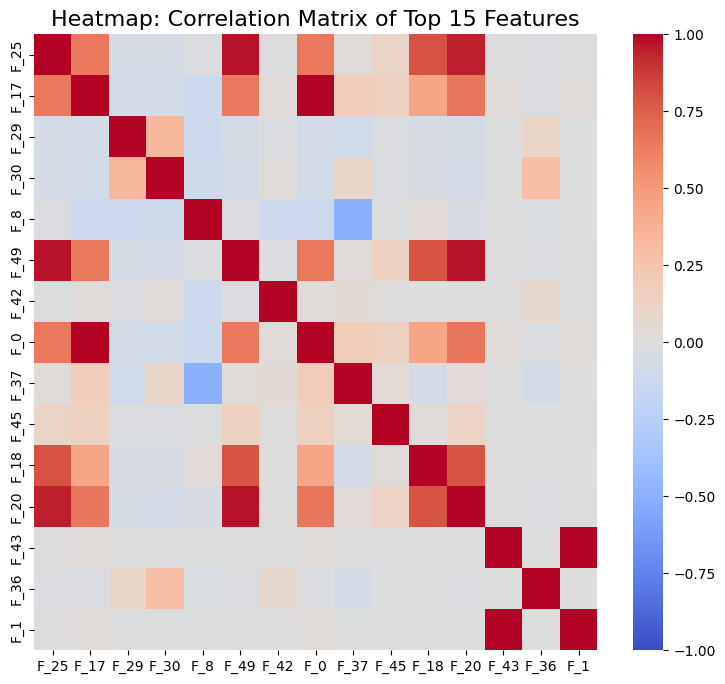


Generating Pairplot (this might take a few seconds...)...



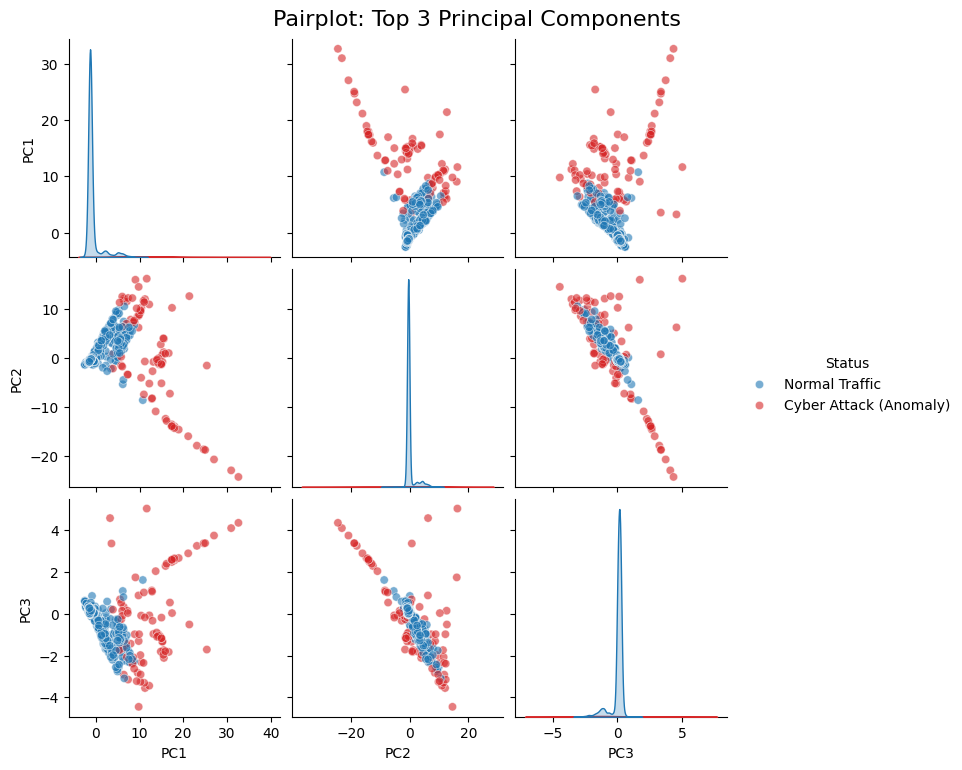

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the figure with 2 subplots side by side
fig = plt.figure(figsize=(20, 8))

# ---- 1. Heatmap (Correlation of top 15 features with highest variance) ----
plt.subplot(1, 2, 1)
# Calculate variances and select top 15 features
feature_variances = X_scaled.var(axis=0)
top_15_idx = np.argsort(feature_variances)[-15:]
top_15_features = X_scaled[:, top_15_idx]

# Calculate correlation matrix
corr_matrix = np.corrcoef(top_15_features, rowvar=False)

sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=[f'F_{i}' for i in top_15_idx],
            yticklabels=[f'F_{i}' for i in top_15_idx])
plt.title('Heatmap: Correlation Matrix of Top 15 Features', fontsize=16)

# ---- 2. Pairplot (using PCA components and a subsample to save memory) ----
# We use the 'pca_df' we already created, sample 2000 rows to prevent crashing
sample_pca = pca_df.sample(n=2000, random_state=42)

# Create the pairplot in a new figure (Seaborn pairplot manages its own figure)
plt.show() # Show the heatmap first

print("\nGenerating Pairplot (this might take a few seconds...)...\n")
sns.pairplot(sample_pca,
             vars=['PC1', 'PC2', 'PC3'],
             hue='Status',
             palette={'Normal Traffic': '#1f77b4', 'Cyber Attack (Anomaly)': '#d62728'},
             plot_kws={'alpha': 0.6},
             diag_kind='kde')
plt.suptitle('Pairplot: Top 3 Principal Components', y=1.02, fontsize=16)
plt.show()